# 04 — Error analysis and fairness slices

Notebook 03 chose the scorer (Random Forest, QWK 0.558 under speaker-grouped CV). This
notebook asks the evaluation-science questions that decide whether such a scorer could be
*used*:

1. **Where is it wrong?** Signed error by proficiency band, calibration, band confusion,
   adjacent-agreement rates.
2. **Why is it wrong?** Does ASR error propagate into scoring error? (WER is available for
   the 600/876 responses with gold transcripts.)
3. **Is it wrong *fairly*?** Error parity across the slices the corpus supports: audio
   quality (Q2–QX), proficiency band, and test part. No L1 metadata exists (see
   `reports/data_gates.md`), so L1 fairness cannot be assessed — stated as a limitation,
   not silently skipped.

*Licence note: all outputs are aggregates — no per-speaker rows, no transcript text.*

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf

from speechlab.data import load_responses
from speechlab.acoustic_features import fluency_features, FLUENCY_FEATURES, PROSODY_FEATURES
from speechlab.text_features import mtld, normalise_tokens
from speechlab.evaluation import evaluate, to_grid

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
CORPUS = ROOT / "data" / "sandi-corpus-2025"
REF = CORPUS / "reference-materials"
DERIVED = ROOT / "data" / "derived"
PARTS = ["P3", "P4"]
SEED = 42

## 1. Rebuild the notebook-03 scorer

Identical feature matrix and CV protocol as notebook 03 (the Random Forest is deterministic
for a fixed seed, so these predictions match notebook 03's table exactly).

In [2]:
frames = []
for part in PARTS:
    df = load_responses(CORPUS, part)
    trans = json.load(open(DERIVED / f"transcripts_{part}_small.json"))
    pros = json.load(open(DERIVED / f"prosody_{part}_full.json"))
    rows = []
    for r in df.itertuples():
        words = trans[r.utt]
        duration = sf.info(str(CORPUS / r.flac)).duration
        rows.append({"utt": r.utt, "speaker": r.speaker, "part": part, "score": r.score,
                     **fluency_features(words, duration),
                     "mtld": mtld(normalise_tokens([w["w"] for w in words])),
                     **pros[r.utt]})
    frames.append(pd.DataFrame(rows))
data = pd.concat(frames, ignore_index=True)
data = data[data.n_words > 0].reset_index(drop=True)
data["part_p4"] = (data.part == "P4").astype(float)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, cross_val_predict

F_MTLD = [f if f != "ttr" else "mtld" for f in FLUENCY_FEATURES]
FEATURES = F_MTLD + PROSODY_FEATURES + ["part_p4"]
y = data.score.to_numpy()
rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=5, random_state=SEED, n_jobs=-1)
pred = cross_val_predict(rf, data[FEATURES].to_numpy(), y,
                         cv=GroupKFold(n_splits=5), groups=data.speaker.to_numpy())
data["pred"] = pred
data["err"] = pred - y                  # signed: positive = over-scored
data["abs_err"] = np.abs(data.err)

headline = evaluate(y, pred)
print({k: round(v, 3) for k, v in headline.items()})

{'pearson_r': np.float64(0.622), 'spearman_rho': np.float64(0.625), 'MAE': 0.456, 'RMSE': 0.575, 'QWK': 0.558}


## 2. Where the scorer is wrong

**Signed** error by band shows the *direction* of failure, not just its size: regression to
the mean predicts over-scoring weak speakers and under-scoring strong ones. Adjacent
agreement (within half a band / one band) is how operational scoring programmes actually
report agreement.

In [3]:
band = data.score.clip(1, 5.99).astype(int)
by_band = data.groupby(band).agg(
    n=("err", "size"), MAE=("abs_err", "mean"), mean_signed_err=("err", "mean")).round(3)
print(by_band)

on_grid = np.abs(to_grid(pred, y.min(), y.max()) - to_grid(y, y.min(), y.max()))
agreement = pd.Series({
    "exact (same 0.5 step)": float((on_grid == 0).mean()),
    "within 0.5": float((on_grid <= 1).mean()),
    "within 1.0": float((on_grid <= 2).mean()),
}).round(3)
print()
print(agreement)

         n    MAE  mean_signed_err
score                             
2       42  0.964            0.964
3      290  0.455            0.361
4      412  0.327           -0.120
5      132  0.701           -0.701

exact (same 0.5 step)    0.341
within 0.5               0.815
within 1.0               0.977
dtype: float64


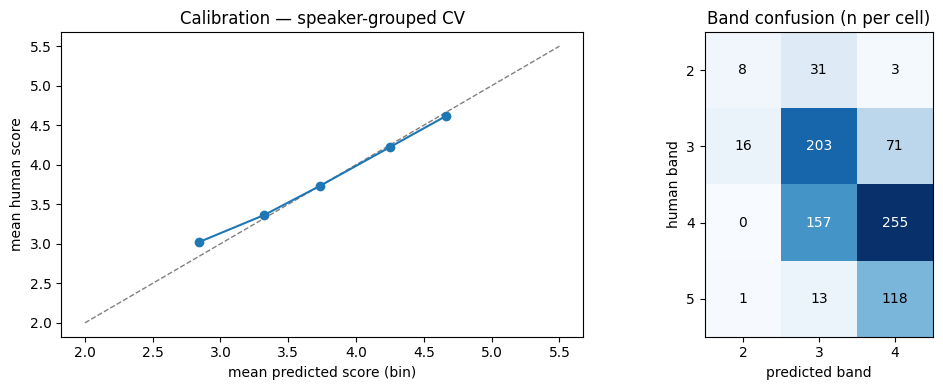

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# calibration: binned predicted vs actual means
bins = pd.cut(data.pred, np.arange(1.5, 6.1, 0.5))
cal = data.groupby(bins, observed=True).agg(pred_mean=("pred", "mean"), true_mean=("score", "mean"))
axes[0].plot([2, 5.5], [2, 5.5], "--", color="grey", lw=1)
axes[0].plot(cal.pred_mean, cal.true_mean, "o-")
axes[0].set_xlabel("mean predicted score (bin)")
axes[0].set_ylabel("mean human score")
axes[0].set_title("Calibration — speaker-grouped CV")

# band confusion (aggregate counts)
conf = pd.crosstab(band, data.pred.clip(1, 5.99).astype(int))
im = axes[1].imshow(conf, cmap="Blues")
axes[1].set_xticks(range(len(conf.columns)), conf.columns)
axes[1].set_yticks(range(len(conf.index)), conf.index)
axes[1].set_xlabel("predicted band")
axes[1].set_ylabel("human band")
axes[1].set_title("Band confusion (n per cell)")
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        axes[1].text(j, i, conf.iloc[i, j], ha="center", va="center",
                     color="white" if conf.iloc[i, j] > conf.values.max() / 2 else "black")
plt.tight_layout()

## 3. Does ASR error propagate into scoring error?

Notebook 02 showed WER rises as proficiency falls. The sharper question for the evaluation
report: holding the response's actual quality aside, **does a badly-transcribed response get
a worse score prediction?** WER is computable for the 600 responses with gold transcripts.

In [5]:
from scipy.stats import pearsonr

from speechlab.asr import parse_stm, parse_stm_tags, wer_pair

gold = parse_stm(REF / "stms" / "dev-asr.stm")
tags = parse_stm_tags(REF / "stms" / "dev-asr.stm")

trans_all = {}
for part in PARTS:
    trans_all |= json.load(open(DERIVED / f"transcripts_{part}_small.json"))

wer_rows = []
for utt in data.utt:
    if utt not in gold:
        continue
    hyp = " ".join(w["w"] for w in trans_all[utt])
    if not hyp.strip():
        continue
    wer_rows.append({"utt": utt, "wer": wer_pair(gold[utt], hyp)["wer_lenient"],
                     "quality": tags[utt]["quality"]})
wer_df = pd.DataFrame(wer_rows)
cov = data.merge(wer_df, on="utt")
print(f"gold coverage: {len(cov)}/{len(data)} responses")

r_err, p_err = pearsonr(cov.wer, cov.abs_err)
r_signed, p_signed = pearsonr(cov.wer, cov.err)
print(f"WER vs |scoring error|:    r = {r_err:+.3f} (p = {p_err:.4f})")
print(f"WER vs signed error:       r = {r_signed:+.3f} (p = {p_signed:.4f})")

cov["wer_q"] = pd.qcut(cov.wer, 4, labels=["Q1 (best ASR)", "Q2", "Q3", "Q4 (worst ASR)"])
print()
print(cov.groupby("wer_q", observed=True).agg(
    n=("abs_err", "size"), MAE=("abs_err", "mean"),
    mean_signed_err=("err", "mean"), mean_score=("score", "mean")).round(3))

# Is that signed-error correlation a real ASR effect, or just proficiency in disguise?
# (low scorers have high WER, and low scorers are over-scored by regression to the mean)
# Partial correlation: residualise both WER and signed error on the human score.
def residualise(v, on):
    beta = np.polyfit(on, v, 1)
    return v - np.polyval(beta, on)

r_partial, p_partial = pearsonr(residualise(cov.wer.to_numpy(), cov.score.to_numpy()),
                                residualise(cov.err.to_numpy(), cov.score.to_numpy()))
print(f"\nWER vs signed error, controlling for score: r = {r_partial:+.3f} (p = {p_partial:.3f})")

gold coverage: 600/876 responses
WER vs |scoring error|:    r = -0.031 (p = 0.4543)
WER vs signed error:       r = +0.151 (p = 0.0002)

                  n    MAE  mean_signed_err  mean_score
wer_q                                                  
Q1 (best ASR)   150  0.463           -0.246       4.327
Q2              151  0.446           -0.087       4.212
Q3              149  0.474            0.038       3.859
Q4 (worst ASR)  150  0.436            0.185       3.540

WER vs signed error, controlling for score: r = -0.013 (p = 0.746)


## 4. Fairness slices

The three slices the corpus supports (no L1 metadata exists — limitation, not choice):
audio quality (Q2 worst – Q5 best, QX unassessable; from STM tags, gold-covered subset),
proficiency band (full set, above), and test part (full set).

In [6]:
qual = cov.groupby("quality").agg(
    n=("abs_err", "size"), MAE=("abs_err", "mean"),
    mean_signed_err=("err", "mean"), mean_WER=("wer", "mean"),
    mean_score=("score", "mean")).round(3)
print("audio quality slice (gold-covered subset):")
print(qual.loc[[q for q in ["Q2", "Q3", "Q4", "Q5", "QX"] if q in qual.index]])

audio quality slice (gold-covered subset):
           n    MAE  mean_signed_err  mean_WER  mean_score
quality                                                   
Q3        22  0.512            0.231     0.321       3.636
Q4       339  0.436            0.020     0.219       3.929
Q5       239  0.477           -0.120     0.186       4.096


test part slice:
        n    MAE  mean_signed_err    QWK
part                                    
P3    438  0.433           -0.007  0.604
P4    438  0.480            0.014  0.496

per-speaker MAE: median 0.387, 90th pct 0.830, max 1.707


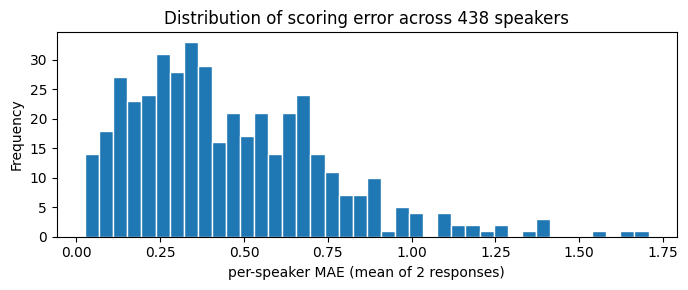

In [7]:
part_slice = data.groupby("part").agg(
    n=("abs_err", "size"), MAE=("abs_err", "mean"), mean_signed_err=("err", "mean")).round(3)
part_slice["QWK"] = [round(evaluate(y[(data.part == p).to_numpy()],
                                    pred[(data.part == p).to_numpy()])["QWK"], 3)
                     for p in part_slice.index]
print("test part slice:")
print(part_slice)

# per-speaker error: each speaker has two responses; is error concentrated in few speakers?
spk = data.groupby("speaker").abs_err.mean()
print(f"\nper-speaker MAE: median {spk.median():.3f}, 90th pct {spk.quantile(0.9):.3f}, "
      f"max {spk.max():.3f}")
fig, ax = plt.subplots(figsize=(7, 3))
spk.plot.hist(bins=40, ax=ax, edgecolor="white")
ax.set_xlabel("per-speaker MAE (mean of 2 responses)")
ax.set_title("Distribution of scoring error across 438 speakers")
plt.tight_layout()

## Findings

**The scorer compresses the scale — and the direction is now measured.** Every band-2
response is over-scored (mean signed error **+0.96**, identical to its MAE) and band 5 is
under-scored by **−0.70**; band 4, where the data mass sits, is near-calibrated (−0.12).
Textbook regression to the mean, but with operational teeth: the scorer flatters exactly
the candidates who should fail and penalises the strongest.

**Agreement in operational terms**: 34% exact on the 0.5-step grid, **81.5% within half a
band, 97.7% within one band**. The calibration curve bends at both ends — the model rarely
predicts below 3 or above 5.

**ASR error does *not* independently propagate into scoring error.** The raw correlation
(WER vs signed error, r = +0.15, p = .0002) looks like "bad transcription → over-scoring",
but controlling for proficiency it vanishes (**r = −0.01, p = .75**). High-WER speakers are
low-proficiency speakers, and low-proficiency speakers are over-scored by band compression —
the WER effect was proficiency in disguise. Notebook 02 raised the alarm; the partial
correlation resolves it. (Caveat: this is whisper-small on features that barely use the
transcript content; LLM-derived text features would re-expose the question.)

**Audio quality slice is reassuringly flat — with caveats.** Q3/Q4/Q5 MAEs sit within 0.08
of each other; the mild signed-error gradient (Q3 +0.23 → Q5 −0.12) tracks each group's mean
proficiency, the same mediation as WER. Only 22 Q3 responses exist in the gold-covered
P3/P4 subset and no Q2/QX at all, so the slice is honest but thin — to be revisited with
P1/P5 when their transcription completes.

**Part parity holds on error size, not on ranking**: MAE 0.43 (P3) vs 0.48 (P4) and signed
error ≈ 0 for both, but QWK drops 0.60 → 0.50 on P4 — the model ranks P4 responses less
well rather than scoring them with bias.

**A tail of speakers is badly served**: median per-speaker MAE 0.39, but the 90th percentile
is 0.83 and the worst speaker averages 1.71 bands of error across their two responses.
Per-candidate reliability, not just aggregate QWK, belongs in the model card.

**No L1 metadata exists in the corpus**, so L1 fairness — the slice that matters most in
the assessment literature — cannot be assessed. Stated as a limitation for the report.

**Next:** the written deliverables (model card + evaluation report in `reports/`), pulling
these tables together; LLM text features and P1/P5 short responses as follow-ups.